<a href="https://colab.research.google.com/github/olchan/DEEPLEARNINGstudy/blob/main/%5B%EB%94%A5%EB%9F%AC%EB%8B%9D%EC%9D%98_%EC%A0%95%EC%84%9D_2%ED%8C%90%5D_Optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Loss Function은 여러개의 local minima가 있어 non convex하다.
-  하나의 은닉층(Hidden Layer)에 여러 개의 뉴런이 있다고 가정해 보겠습니다. 1번 뉴런과 2번 뉴런의 위치를 서로 바꾸고, 그 뉴런들과 연결된 앞뒤 가중치(Weight)들도 함께 자리를 바꿔주어도 다음 층으로 전달되는 최종 출력값의 합은 자리를 바꾸기 전과 100% 동일하다. 가중치가 바뀌었는데 모델의 출력(성능)이 똑같다는 것은, Loss(오차) 값도 완전히 똑같다 는 뜻인데, 이는 곧, 공간상에 성능이 완벽히 똑같은 최솟값(Minimum)이 수십만, 수백만 개가 격자처럼 흩어져서 존재한다는 것을 의미하며  Loss Function이 "Non - Convex"함을 의미한다.

> ReLU 의 성질

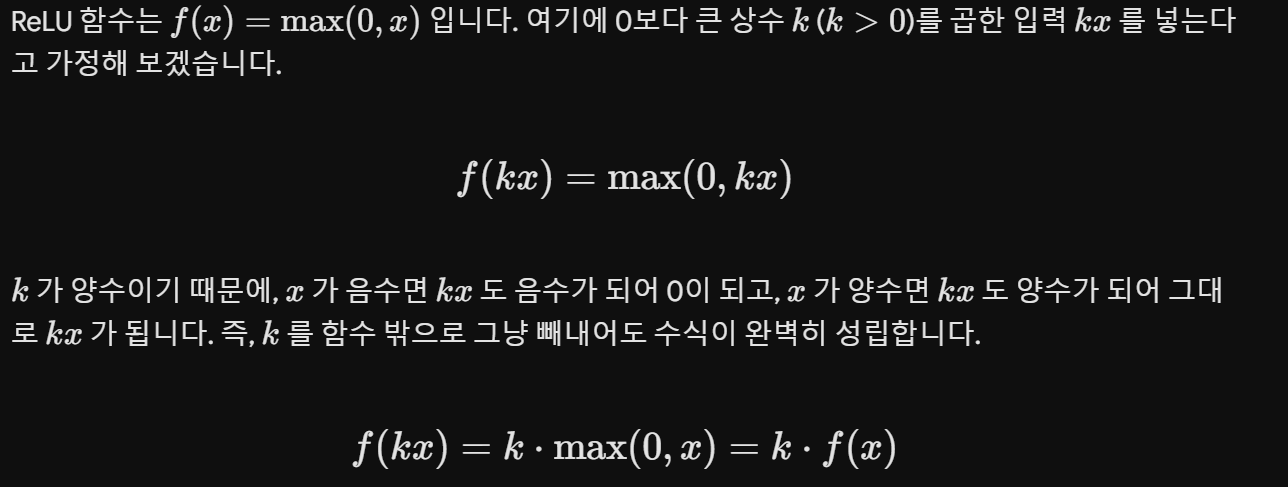

> 신경망에서의 가중치 주고 받기

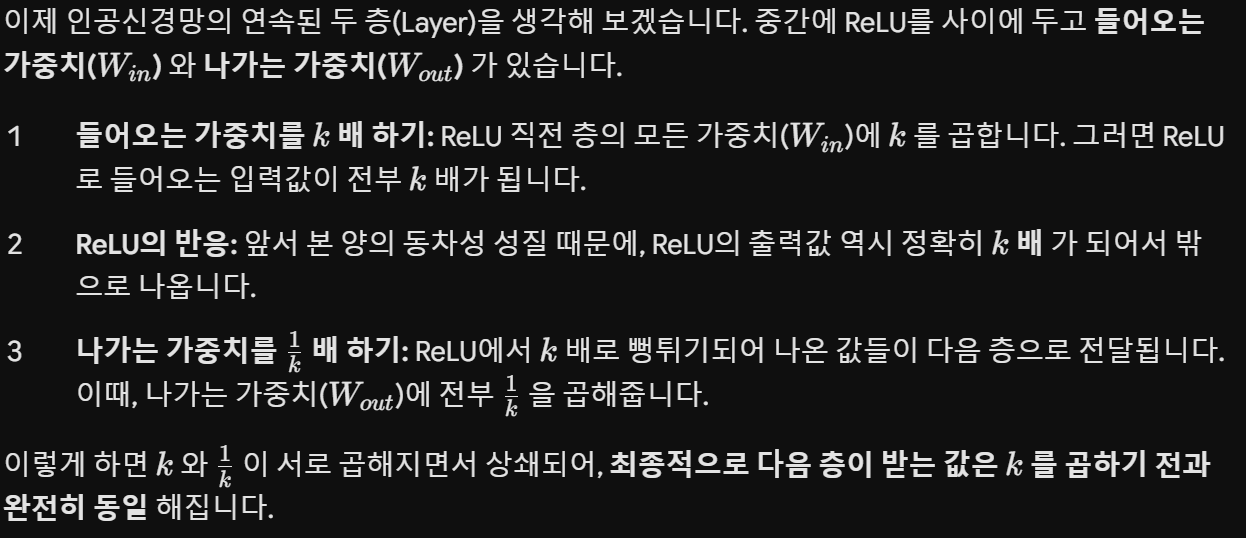

> 이러한 ReLU의 성질을 활용한다면?

- 딥러닝 모델의 가중치 노름(Weight Norm) 제어 나 정규화(Normalization), 그리고 모델 압축(Pruning 및 Quantization) 연구에서 매우 중요하게 다뤄집니다.

- 동일한 성능, 다른 가중치: 가중치의 숫자는 완전히 바뀌었지만(스케일링), 신경망이 예측하는 결과(동작)는 1%도 변하지 않습니다. 즉, 딥러닝 모델의 손실 함수(Loss) 공간에는 이처럼 가중치 스케일만 다르고 성능은 똑같은 수많은 동등한 상태(Equivalence class) 가 존재한다는 것을 의미합니다.

- 가중치 크기 균형 맞추기: 특정 층의 가중치가 너무 커서 그래디언트 폭발(Exploding)이 우려되거나, 반대로 너무 작아서 소실(Vanishing)될 것 같다면, ReLU의 이 성질을 이용해 네트워크의 출력은 건드리지 않으면서 가중치들의 스케일(크기)만 예쁘게 재조정(Re-balancing)할 수 있습니다.

> **Loss Monotonicity** : 직관적으로는 수많은 극소점이 가로막아야 할 것 같지만, 차원이 극도로 높아지면서 공간에 여유 부피가 엄청나게 늘어난 덕분에, random하게 초기화된 지점과 SGD 해 사이에는 평탄한 직선 구간이 통계적으로 항상 존재한다는 점이 밝혀졌기에, 딥러닝 모델들은 비볼록 오차 표면을 가졌음에도 불구하고, 초기화 위치에 상관없이 꽤나 쉽게 학습(수렴)에 성공할 수 있다.

> 다만, loss function에는 매우 많은 안장점들이 존재하기에, 이러한 안장점들을 빠져나오기 위해서는 momentum 기반의 optimizer가 필요하다.

### Momentum
- momentum을 추가하면, train 시간을 줄일 수 있다.

## Adagrad
- 시간에 따라 학습률을 조정하는 알고리즘

>> 배경 : 일반 경사하강법은 모든 파라미터에 동일한 학습률(Learning Rate) 을 적용. 다만, 모델 안에는 자주 업데이트되는 가중치가 있고, 드물게 업데이트되는 가중치가 있기에, 가중치 업데이트가 많았던 파라미터의 학습률은 줄이고, 적었던 파라미터의 학습률은 늘린다.

In [ ]:
optimizer = optim.Adagrad(model.parameters(), lr = 0.01, weight_decay = 0, initial_accumulator_value = 0)

>> 대부분의 딥러닝 논문이 '아이디어 $\rightarrow$ 수식 $\rightarrow$ 실험'의 공학적 흐름을 따르지만, 수학적 이론이 먼저 정립되고 나중에 딥러닝에 도입된 case도 존재한다.

- Optimal Transport (최적 운송 이론): 18세기 수학자 몽주(Monge)가 정립한 수학 이론인데, 수백 년이 지난 지금 GAN(생성 적대 신경망)의 학습을 안정화하는 Wasserstein GAN (WGAN) 의 Loss 수식을 설계하는 데 결정적인 역할을 했습니다.

- Diffusion 모델: 열역학(Thermodynamics)에서 기체 분자가 확산되는 물리 법칙과 수학 수식을 그대로 AI 이미지 생성에 대입했더니 기가 막힌 성능을 낸 케이스입니다.

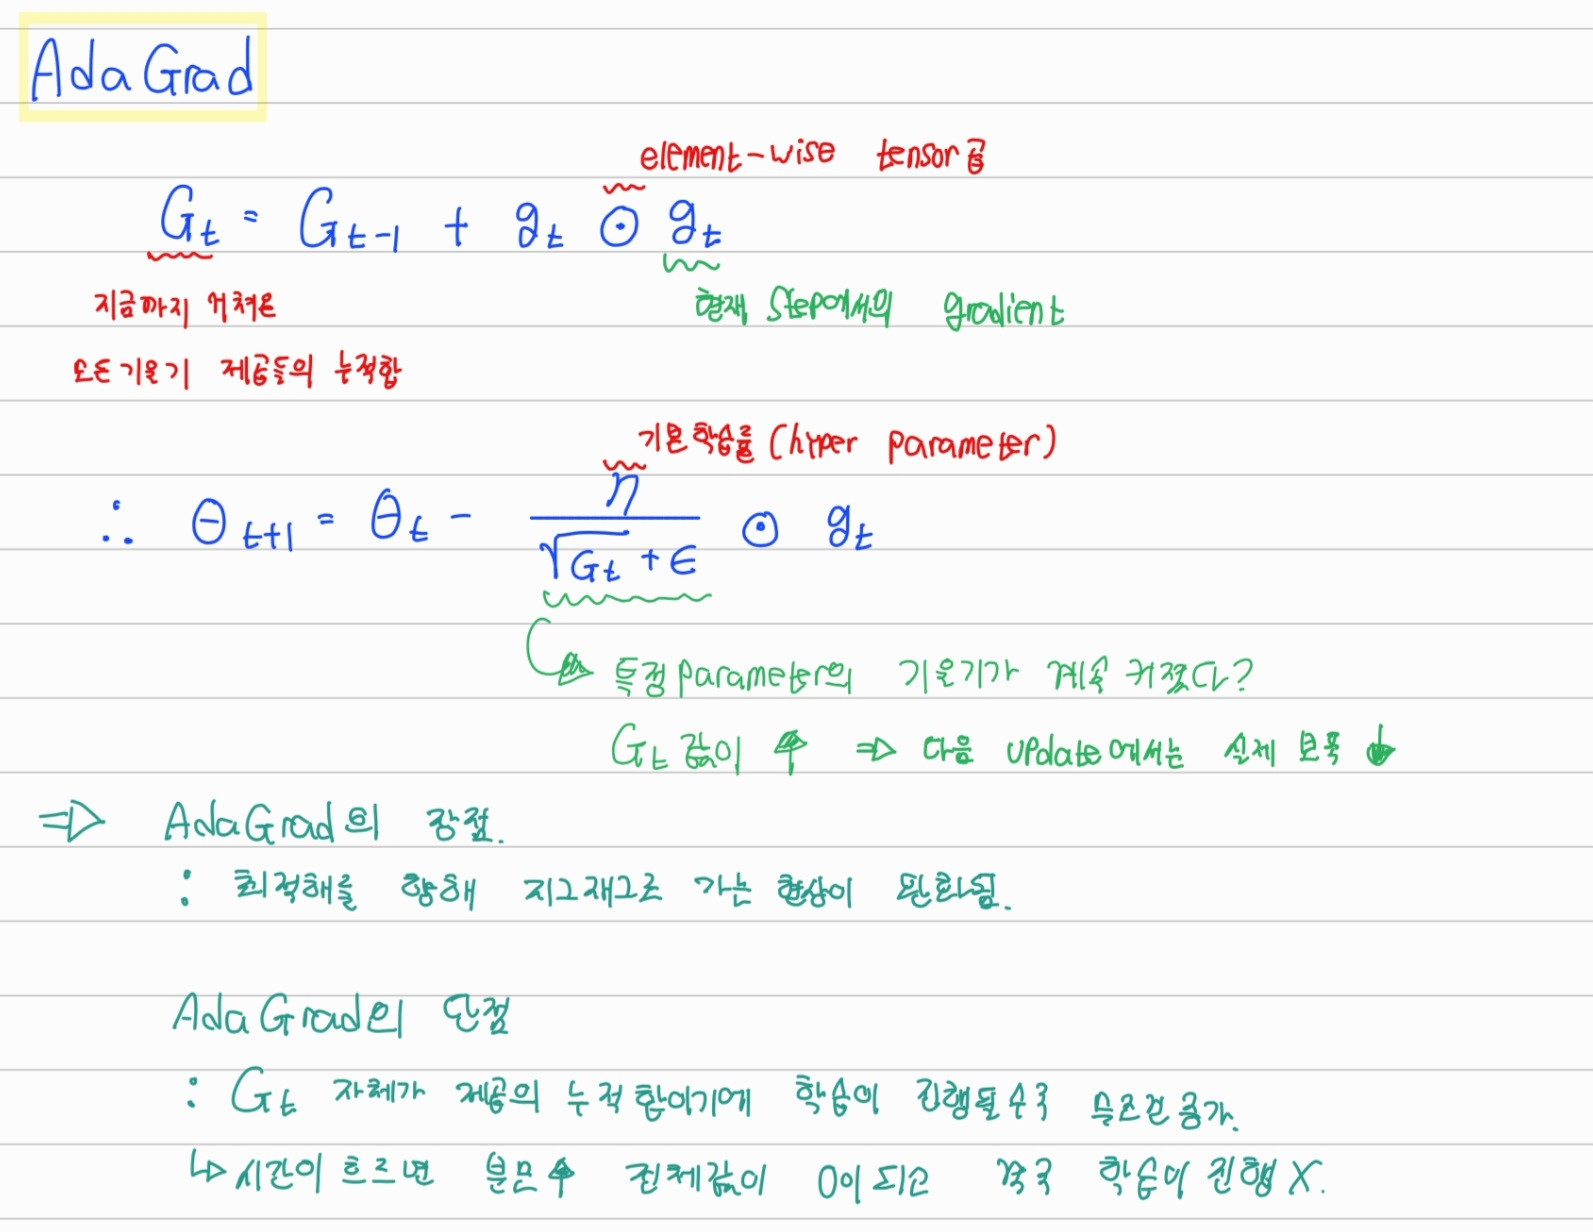

## RMSProp : 경사 지수 가중 이동 평균
- adagrad를 사용하면 학습률이 조기에 떨어져서 학습이 끝까지 잘 되지 않아, 고안된 방법론

- 단순히 경사를 누적하지 않고, 오래 전에 만든 측정값을 버린다는 것이 특징


In [ ]:
optimizer = optim.RMSprop(model.parameters(),
                          lr = 0.01,
                          alpha = 0.99,
                          eps = 1e-8,
                          weight_decay = 0,
                          momentum = 0)

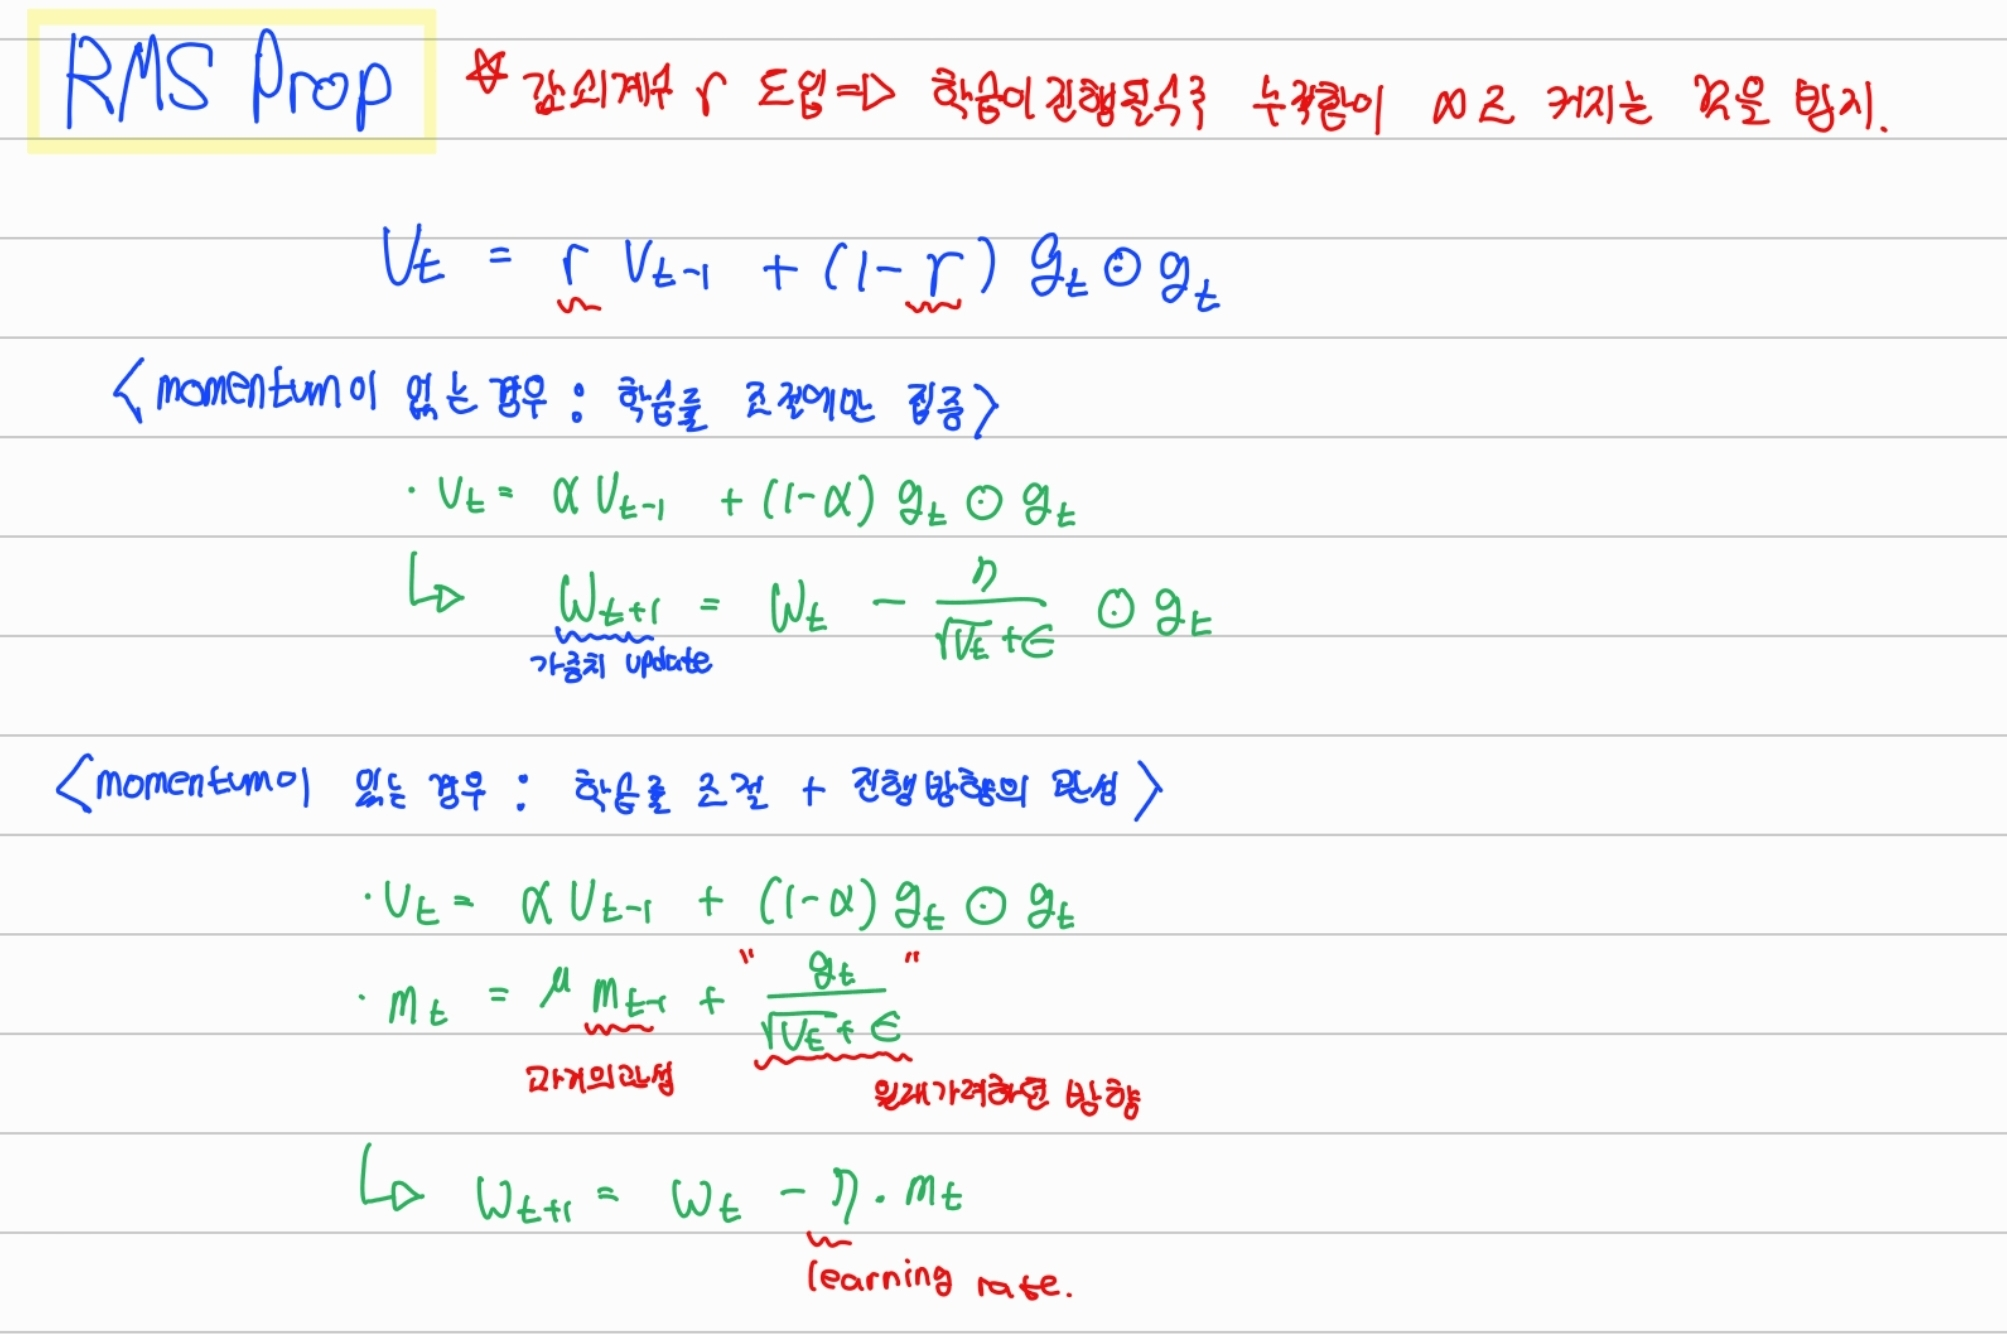

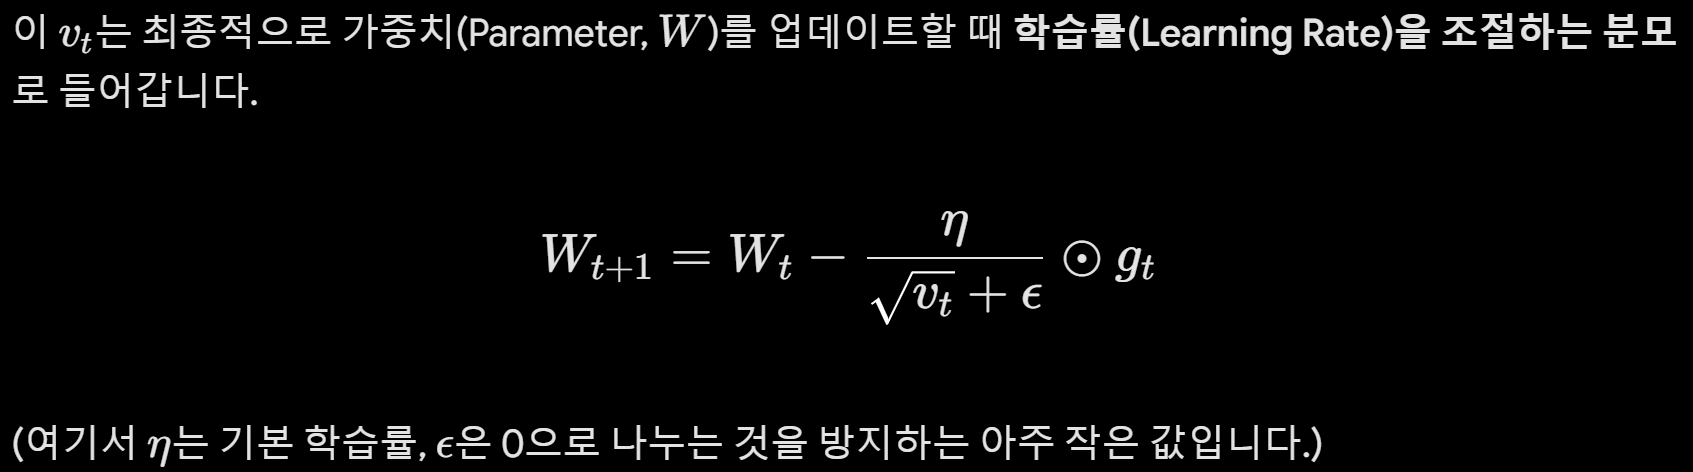

# ADAM : Momentum + RMSProp + Bias Correction
- 방향을 담당하는 'Momentum': "지그재그로 요동치지 말고, 원래 가던 방향으로 관성을 가지고 묵직하게 밀고 나가자!"

- 보폭을 담당하는 'RMSprop': "가파른 길에서는 보폭을 줄이고, 완만한 길에서는 보폭을 넓혀서 축별로 맞춤형 보폭(학습률)을 가져가자!"

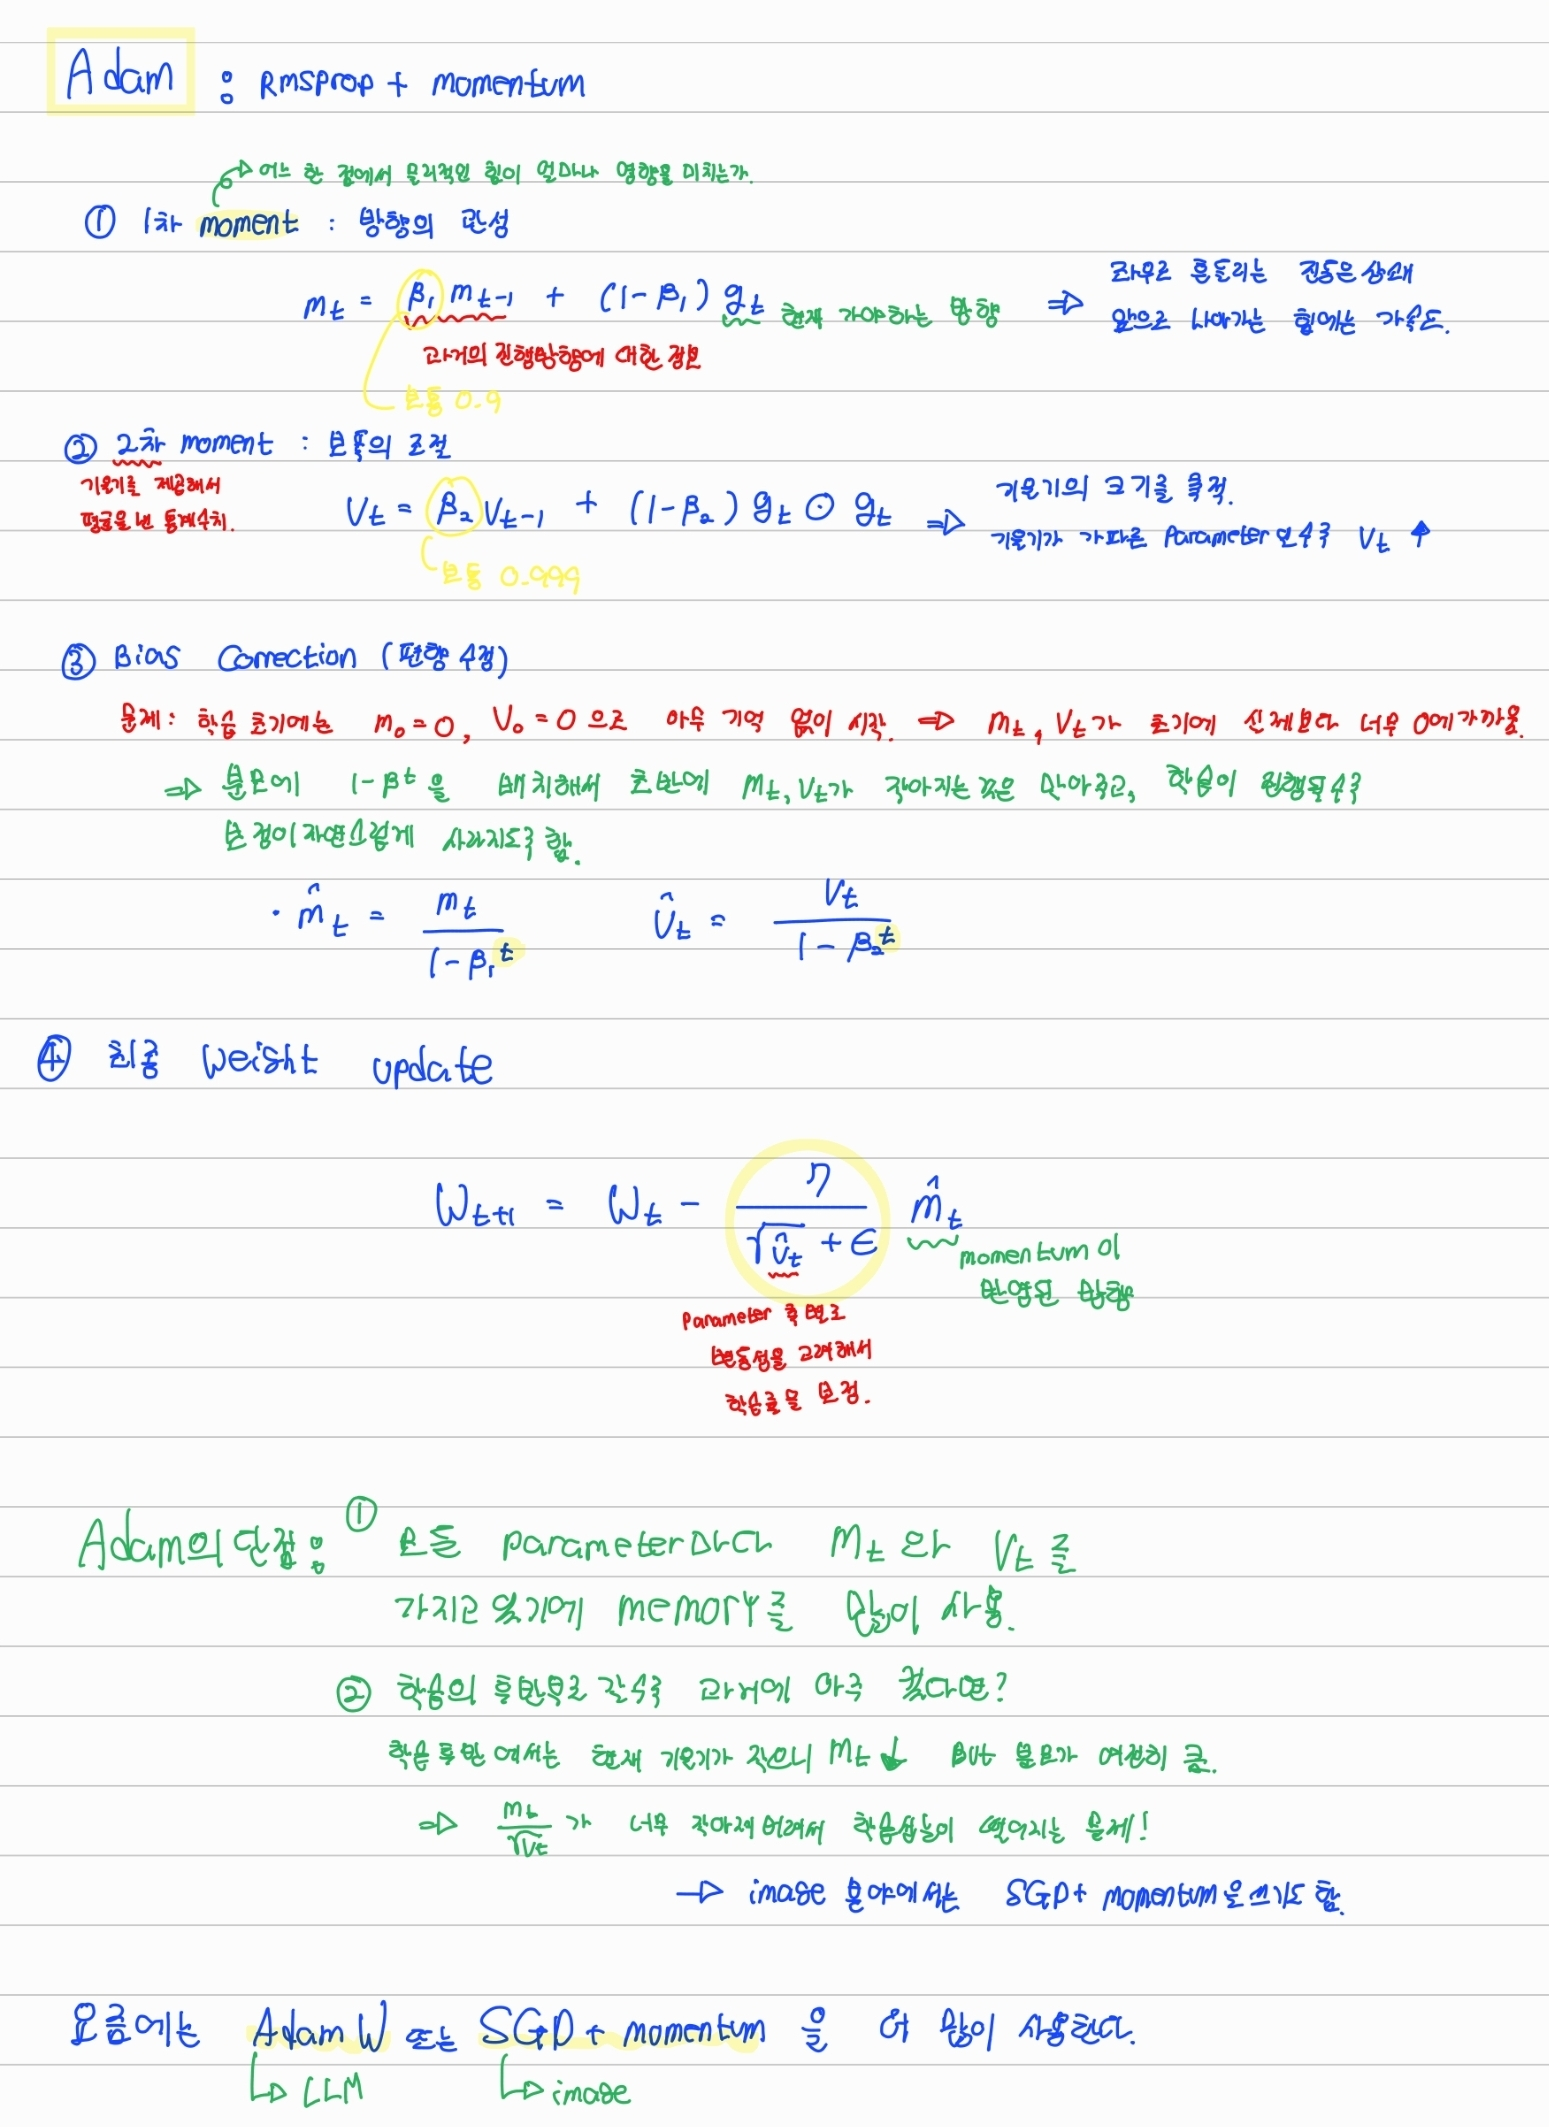

>> momentum은 지수이동평균임. 초기의 gradient일수록 지수적으로 계수가 작아지고, 평균이 게속해서 이동하기 때문

>> RMSProp에 Momentum을 추가해도 Adam과 매우 비슷한 효과를 얻을 수 있다. 하지만 Adam은 1차·2차 모멘트를 대칭적으로 관리하고, 초기 편향 보정(Bias Correction)을 포함하며, 기본 하이퍼파라미터가 다양한 문제에서 안정적으로 작동하도록 설계된 최적화 알고리즘이다. 그래서 RMSProp+Momentum의 사실상 표준화된 형태로 널리 사용되게 되었다.

In [ ]:
optimizer = optim.Adam(model.parameters(),
                       lr = 0.001,
                       betas = (0.9, 0.999),
                       eps = 1e-08,
                       weight_decay = 0,
                       amsgrad = False)

### Optimizer switching 이라는 기법이 있기는 하나, hyper parameter가 너무 많고, 학습 도중 optimizer를 바꾸는 과정에서 learning rate과 switching timing을 맞추기가 매우 어려움.
- SWATS (Switching from Adam to SGD)

### 대신 최근에는 AdamW + Cosine Annealing Scheduler를 많이 사용한다.
- 후반부 수렴 성능을 SGD 급으로 끌어올린 알고리즘

- Adam 은 이미 L2 규제를 잘못된 방식으로 하고 있었고, AdamW 는 그것을 올바르게 분리(Decoupled)
- Weight (가중치)를 업데이트하는 타이밍에서 adam과 차이를 두어 성능이 급격히 증가

In [ ]:
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

# 1. 옵티마이저는 가중치 감쇠가 수리적으로 분리된 AdamW를 고른다.
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# 2. 뒤에 스케줄러로 코사인 어닐링(with Restarts)을 붙인다.
# 여기서 T_0가 주기, T_mult가 주기를 늘려나가는 승수입니다.
scheduler = lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

>> **더 좋은 optimizer를 발견하는 것보다는 더 쉽게 train 가능한 architecture를 발견하는 방향으로 연구들은 발전되고 있다.**